## Imports & Setup

In [1]:
import sys
sys.path.append("..")

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
import matplotlib.pyplot as plt
import json
from pathlib import Path

from app.models.transformer import BehavioralTransformer, TransformerConfig
from app.models.gan_autoencoder import GANAutoencoderKYC
from app.models.ensemble import ModelEnsemble
from synthetic_data_generator.behavioral import (
    UserProfileGenerator, TransactionSequenceGenerator, AnomalyInjector
)
from synthetic_data_generator.kyc import DocumentMetadataGenerator, ForgerySimulator

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CHECKPOINT_DIR = Path("../checkpoints")
CHECKPOINT_DIR.mkdir(exist_ok=True)
print(f"Training on: {DEVICE}")


Training on: cpu


## Generate / Load Behavioral Data

In [2]:
print("Generating behavioral data...")
profiles = UserProfileGenerator(seed=42).generate_batch(n_users=500, n_fraud_users=50)
seq_gen  = TransactionSequenceGenerator(seed=42)
injector = AnomalyInjector(seed=42)

sequences, labels = [], []
for profile in profiles:
    seq = seq_gen.generate_for_user(profile, n_transactions=50)
    label = 0
    if np.random.random() < 0.15:
        seq = injector.inject(seq, profile)
        label = 1

    # Encode to (50, 32) — reuse the same encoder as sequential_service
    from app.services.sequential_service import _transaction_to_vector
    vectors = [_transaction_to_vector(t) for t in seq[-50:]]
    while len(vectors) < 50:
        vectors.insert(0, np.zeros(32, dtype=np.float32))
    sequences.append(np.stack(vectors, axis=0))
    labels.append(label)

X = torch.tensor(np.array(sequences), dtype=torch.float32)
y = torch.tensor(labels, dtype=torch.float32).unsqueeze(1)

print(f"Dataset: {len(X)} sequences | Fraud rate: {y.mean().item():.2%}")


Generating behavioral data...
Dataset: 500 sequences | Fraud rate: 16.20%


## Train/Val Split & DataLoaders

In [3]:
dataset = TensorDataset(X, y)
n_train = int(0.8 * len(dataset))
n_val   = len(dataset) - n_train
train_ds, val_ds = random_split(dataset, [n_train, n_val])

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=32, shuffle=False)

print(f"Train: {n_train} | Val: {n_val}")


Train: 400 | Val: 100


## Train Behavioral Transformer

In [6]:
config = TransformerConfig()
model  = BehavioralTransformer(config).to(DEVICE)
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)

# Class-weighted BCE for imbalanced data
pos_weight = torch.tensor([(y == 0).sum() / (y == 1).sum()]).to(DEVICE)
criterion  = nn.BCELoss()

def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct = 0.0, 0
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        preds, _ = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(xb)
        correct += ((preds > 0.5).float() == yb).sum().item()
    return total_loss / len(loader.dataset), correct / len(loader.dataset)

def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct = 0.0, 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            preds, _ = model(xb)
            loss = criterion(preds, yb)
            total_loss += loss.item() * len(xb)
            correct += ((preds > 0.5).float() == yb).sum().item()
    return total_loss / len(loader.dataset), correct / len(loader.dataset)

EPOCHS = 25
train_losses, val_losses = [], []

for epoch in range(EPOCHS):
    tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion)
    vl_loss, vl_acc = eval_epoch(model, val_loader, criterion)
    train_losses.append(tr_loss)
    val_losses.append(vl_loss)
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:02d} | "
              f"Train Loss: {tr_loss:.4f} Acc: {tr_acc:.3f} | "
              f"Val Loss: {vl_loss:.4f} Acc: {vl_acc:.3f}")


Epoch 05 | Train Loss: 0.4608 Acc: 0.830 | Val Loss: 0.3886 Acc: 0.870
Epoch 10 | Train Loss: 0.4621 Acc: 0.830 | Val Loss: 0.3933 Acc: 0.870
Epoch 15 | Train Loss: 0.4528 Acc: 0.830 | Val Loss: 0.3905 Acc: 0.870
Epoch 20 | Train Loss: 0.4552 Acc: 0.830 | Val Loss: 0.3898 Acc: 0.870
Epoch 25 | Train Loss: 0.4530 Acc: 0.830 | Val Loss: 0.3884 Acc: 0.870


## Plot Training Curves

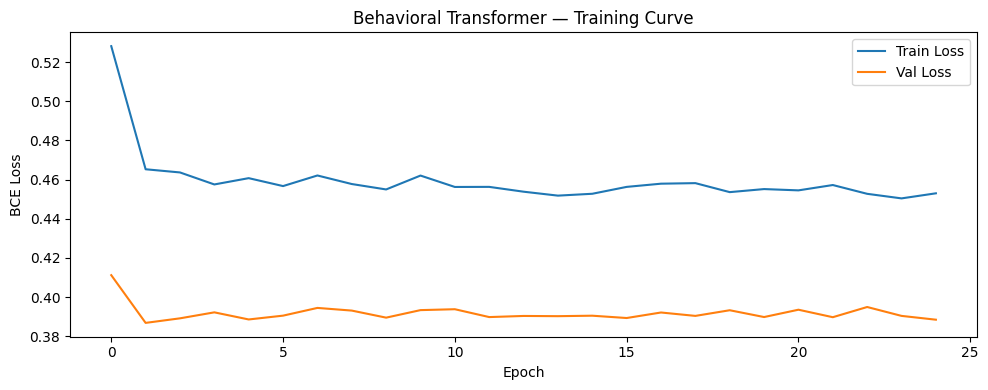

In [7]:
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses,   label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("BCE Loss")
plt.title("Behavioral Transformer — Training Curve")
plt.legend()
plt.tight_layout()
plt.savefig("transformer_training.png", dpi=150)
plt.show()

## Save Checkpoint

In [ ]:
torch.save(model.state_dict(), CHECKPOINT_DIR / "transformer.pt")
print(f" Transformer saved → {CHECKPOINT_DIR / 'transformer.pt'}")

In [ ]:
# Cell — CNN-GNN Hybrid Training (Payment Injection)
import json
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
from sklearn.metrics import classification_report, roc_auc_score
from pathlib import Path

from app.models.cnn_gnn import CNNGNNHybrid

DEVICE         = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CHECKPOINT_DIR = Path("../checkpoints")
CHECKPOINT_DIR.mkdir(exist_ok=True)

# ── Load Payload Data ──────────────────────────────────────────
print("Loading payload data...")
with open("../synthetic_data_generator/outputs/payload/payloads.json") as f:
    payloads = json.load(f)

print(f"Total payloads: {len(payloads):,} | "
      f"Fraud: {sum(p.get('label',0) for p in payloads):,}")


def encode_payload(p: dict) -> np.ndarray:
    """
    Encode a raw Squad payload dict into a 64-dim numeric feature vector.
    Mirrors the encoding in app/services/graph_service.py _encode_payload().
    """
    import re

    def safe_float(v, default=0.0):
        try:
            return float(v)
        except (TypeError, ValueError):
            return default

    amount           = safe_float(p.get("amount", 0)) / 10_000_000.0
    ref              = str(p.get("transaction_ref", ""))
    ref_len_ok       = float(len(ref) == 12)
    ref_alphanumeric = float(bool(re.match(r'^[A-Z0-9]{12}$', ref)))
    has_ip           = float(bool(p.get("ip_address")))
    has_device       = float(bool(p.get("device_id")))
    has_email        = float(bool(p.get("customer_email")))
    currency_ngn     = float(p.get("currency", "") == "NGN")
    channel_enc      = {
        "app": 0.1, "ussd": 0.2, "web": 0.3, "pos": 0.4, "payment_link": 0.5
    }.get(p.get("channel", ""), 0.0)

    # IP anomaly signals
    ip = str(p.get("ip_address", ""))
    ip_parts         = ip.split(".")
    ip_valid_format  = float(len(ip_parts) == 4 and all(
        p_val.isdigit() and 0 <= int(p_val) <= 255 for p_val in ip_parts
    ) if ip_parts else False)
    ip_is_zero       = float(ip == "0.0.0.0")
    ip_is_empty      = float(ip == "")

    # Amount anomaly signals
    amt_raw          = p.get("amount", 0)
    amount_negative  = float(safe_float(amt_raw, 0) < 0)
    amount_zero      = float(safe_float(amt_raw, 1) == 0)
    amount_huge      = float(safe_float(amt_raw, 0) > 500_000_000)
    amount_is_string = float(isinstance(amt_raw, str))

    # Timestamp anomaly signals
    from datetime import datetime
    ts = str(p.get("created_at", ""))
    try:
        dt             = datetime.fromisoformat(ts.replace("Z", "+00:00"))
        ts_valid       = 1.0
        ts_future      = float(dt.year > 2026)
        ts_ancient     = float(dt.year < 2018)
    except Exception:
        ts_valid, ts_future, ts_ancient = 0.0, 0.0, 0.0

    # Missing required fields
    required = ["transaction_ref", "amount", "currency",
                "customer_email", "ip_address", "device_id", "created_at"]
    missing_count = sum(1 for r in required if r not in p or p[r] is None) / len(required)

    features = [
        amount, ref_len_ok, ref_alphanumeric, has_ip, has_device,
        has_email, currency_ngn, channel_enc, ip_valid_format,
        ip_is_zero, ip_is_empty, amount_negative, amount_zero,
        amount_huge, amount_is_string, ts_valid, ts_future,
        ts_ancient, missing_count,
    ]

    # Pad to 64 dims
    features += [0.0] * (64 - len(features))
    return np.array(features[:64], dtype=np.float32)


# ── Encode all payloads ────────────────────────────────────────
payload_features = np.array([encode_payload(p) for p in payloads])
payload_labels   = np.array([p.get("label", 0) for p in payloads], dtype=np.float32)

# Graph embeddings: synthesized from payload features
# In production these come from GraphService. For training,
# we derive them by projecting the payload features through
# a fixed random projection — consistent and reproducible.
rng              = np.random.RandomState(42)
projection       = rng.randn(64, 64).astype(np.float32)
graph_embeddings = np.tanh(payload_features @ projection)

print(f"Payload features: {payload_features.shape}")
print(f"Graph embeddings: {graph_embeddings.shape}")
print(f"Fraud rate:       {payload_labels.mean():.2%}")

# ── Dataset & Loaders ──────────────────────────────────────────
X_pf  = torch.tensor(payload_features, dtype=torch.float32)
X_ge  = torch.tensor(graph_embeddings, dtype=torch.float32)
y     = torch.tensor(payload_labels,   dtype=torch.float32).unsqueeze(1)

dataset  = TensorDataset(X_pf, X_ge, y)
n_train  = int(0.8 * len(dataset))
n_val    = len(dataset) - n_train
train_ds, val_ds = random_split(dataset, [n_train, n_val],
                                generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=64, shuffle=False)
print(f"Train: {n_train:,} | Val: {n_val:,}")

# ── Model, Optimizer, Loss ─────────────────────────────────────
model     = CNNGNNHybrid(payload_input_dim=64, graph_embedding_dim=64).to(DEVICE)
optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-5)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30)

# Weighted BCE to handle class imbalance
fraud_weight = float((y == 0).sum() / (y == 1).sum().clamp(min=1))
criterion    = nn.BCELoss(weight=torch.tensor([fraud_weight]).to(DEVICE))


def cnn_gnn_train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, n = 0.0, 0, 0
    for pf, ge, yb in loader:
        pf, ge, yb = pf.to(DEVICE), ge.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        preds = model(pf, ge)
        loss  = criterion(preds, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item() * len(pf)
        correct    += ((preds > 0.5).float() == yb).sum().item()
        n          += len(pf)
    return total_loss / n, correct / n


def cnn_gnn_eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []
    with torch.no_grad():
        for pf, ge, yb in loader:
            pf, ge, yb = pf.to(DEVICE), ge.to(DEVICE), yb.to(DEVICE)
            preds       = model(pf, ge)
            loss        = criterion(preds, yb)
            total_loss += loss.item() * len(pf)
            all_preds.extend(preds.cpu().numpy().flatten())
            all_labels.extend(yb.cpu().numpy().flatten())
    n       = sum(len(pf) for pf, ge, yb in loader)
    acc     = sum((p > 0.5) == l for p, l in zip(all_preds, all_labels)) / max(len(all_preds), 1)
    auc     = roc_auc_score(all_labels, all_preds) if len(set(all_labels)) > 1 else 0.0
    return total_loss / max(n, 1), acc, auc, all_preds, all_labels


# ── Training Loop ──────────────────────────────────────────────
EPOCHS = 30
train_losses, val_aucs = [], []
best_auc, best_state   = 0.0, None

for epoch in range(EPOCHS):
    tr_loss, tr_acc = cnn_gnn_train_epoch(model, train_loader, optimizer, criterion)
    vl_loss, vl_acc, vl_auc, vl_preds, vl_labels = cnn_gnn_eval_epoch(
        model, val_loader, criterion
    )
    scheduler.step()
    train_losses.append(tr_loss)
    val_aucs.append(vl_auc)

    if vl_auc > best_auc:
        best_auc   = vl_auc
        best_state = {k: v.clone() for k, v in model.state_dict().items()}

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:02d} | "
              f"Train Loss: {tr_loss:.4f} Acc: {tr_acc:.3f} | "
              f"Val Loss: {vl_loss:.4f} Acc: {vl_acc:.3f} AUC: {vl_auc:.4f}")

# Load best weights before saving
model.load_state_dict(best_state)

# ── Final Evaluation ───────────────────────────────────────────
_, _, final_auc, final_preds, final_labels = cnn_gnn_eval_epoch(
    model, val_loader, criterion
)
binary_preds = [1 if p > 0.5 else 0 for p in final_preds]
print(f"\nCNN-GNN Best AUC-ROC: {final_auc:.4f}")
print(classification_report(final_labels, binary_preds, target_names=["Legit", "Fraud"]))

# ── Plot ───────────────────────────────────────────────────────
import matplotlib.pyplot as plt
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(train_losses, color="#2980B9", label="Train Loss")
ax1.set_title("CNN-GNN Training Loss")
ax1.set_xlabel("Epoch")
ax1.legend()

ax2.plot(val_aucs, color="#27AE60", label="Val AUC-ROC")
ax2.axhline(y=best_auc, color="#E74C3C", linestyle="--", label=f"Best: {best_auc:.4f}")
ax2.set_title("CNN-GNN Validation AUC-ROC")
ax2.set_xlabel("Epoch")
ax2.legend()
plt.tight_layout()
plt.savefig("cnn_gnn_training.png", dpi=150)
plt.show()

# ── Save Checkpoint ────────────────────────────────────────────
torch.save(model.state_dict(), CHECKPOINT_DIR / "cnn_gnn.pt")
print(f" CNN-GNN saved → {CHECKPOINT_DIR / 'cnn_gnn.pt'}")

In [ ]:
# Cell — TSSGC Training (SIM Swap Detection)
import json
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
from sklearn.metrics import classification_report, roc_auc_score
from dataclasses import asdict

from app.models.tssgc import SIMSwapDetector
from synthetic_data_generator.sim_swap.device_profile_generator import (
    DeviceProfileGenerator,
    UserDeviceHistory,
    DeviceEvent,
)

DEVICE         = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CHECKPOINT_DIR = Path("../checkpoints")
SEQ_LEN        = 30
DEVICE_DIM     = 32
ACCOUNT_DIM    = 32

# ── Load SIM Swap Data ─────────────────────────────────────────
print("Loading SIM swap data...")
with open("../synthetic_data_generator/outputs/sim_swap/device_histories.json") as f:
    raw_histories = json.load(f)

print(f"Total users: {len(raw_histories):,} | "
      f"With swaps: {sum(1 for h in raw_histories if h['has_sim_swap']):,}")


def events_to_matrix(events: list[dict], seq_len: int, dim: int) -> np.ndarray:
    """
    Convert a list of device event dicts to a (seq_len, dim) feature matrix.
    Truncates or zero-pads to exactly seq_len.
    """
    rows = []
    for ev in events:
        features = [
            float(ev.get("is_sim_swap", False)),
            float(ev.get("is_legitimate_upgrade", False)),
            float(ev.get("location_lat", 0.0)) / 90.0,
            float(ev.get("location_lng", 0.0)) / 180.0,
            abs(hash(ev.get("imei", ""))) % 1000 / 1000.0,
            abs(hash(ev.get("imsi", ""))) % 1000 / 1000.0,
            abs(hash(ev.get("carrier", ""))) % 10 / 10.0,
            abs(hash(ev.get("device_brand", ""))) % 10 / 10.0,
            float(ev.get("device_os", "") == "Android"),
        ]
        features += [0.0] * (dim - len(features))
        rows.append(features[:dim])

    # Pad or truncate to seq_len
    while len(rows) < seq_len:
        rows.insert(0, [0.0] * dim)
    rows = rows[-seq_len:]
    return np.array(rows, dtype=np.float32)


def history_to_account_vector(events: list[dict], dim: int) -> np.ndarray:
    """
    Summarize the pre-swap portion of the device history into a fixed-size
    account fingerprint vector. This is what the model treats as "normal"
    for this account. Uses the first 70% of events (pre-swap window).
    """
    pre_swap = events[:max(1, int(len(events) * 0.7))]
    if not pre_swap:
        return np.zeros(dim, dtype=np.float32)

    carriers = [abs(hash(e.get("carrier", ""))) % 10 / 10.0 for e in pre_swap]
    imeis    = [abs(hash(e.get("imei", ""))) % 1000 / 1000.0 for e in pre_swap]
    lats     = [float(e.get("location_lat", 0.0)) / 90.0 for e in pre_swap]
    lngs     = [float(e.get("location_lng", 0.0)) / 180.0 for e in pre_swap]

    features = [
        float(np.mean(carriers)),
        float(np.std(carriers)),
        float(np.mean(imeis)),
        float(np.std(imeis)),
        float(np.mean(lats)),
        float(np.std(lats)),
        float(np.mean(lngs)),
        float(np.std(lngs)),
        len(pre_swap) / 100.0,
        float(np.mean([e.get("device_os", "") == "Android" for e in pre_swap])),
    ]
    features += [0.0] * (dim - len(features))
    return np.array(features[:dim], dtype=np.float32)


# ── Encode All Histories ───────────────────────────────────────
device_sequences = []
account_histories = []
labels = []

for h in raw_histories:
    events   = h.get("events", [])
    if len(events) < 5:
        continue

    seq      = events_to_matrix(events, SEQ_LEN, DEVICE_DIM)
    acct     = history_to_account_vector(events, ACCOUNT_DIM)
    label    = int(h.get("has_sim_swap", False))

    device_sequences.append(seq)
    account_histories.append(acct)
    labels.append(label)

X_seq  = torch.tensor(np.array(device_sequences),  dtype=torch.float32)
X_acct = torch.tensor(np.array(account_histories), dtype=torch.float32)
y      = torch.tensor(labels, dtype=torch.float32).unsqueeze(1)

print(f"Encoded: {len(labels):,} users | "
      f"Fraud rate: {y.mean().item():.2%} | "
      f"Seq shape: {X_seq.shape}")

# ── Dataset & Loaders ──────────────────────────────────────────
dataset  = TensorDataset(X_seq, X_acct, y)
n_train  = int(0.8 * len(dataset))
n_val    = len(dataset) - n_train
train_ds, val_ds = random_split(dataset, [n_train, n_val],
                                generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False)
print(f"Train: {n_train:,} | Val: {n_val:,}")

# ── Model, Optimizer, Loss ─────────────────────────────────────
model     = SIMSwapDetector(
    device_feature_dim=DEVICE_DIM,
    account_feature_dim=ACCOUNT_DIM,
    hidden_dim=128,
    num_layers=2,
).to(DEVICE)

optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

fraud_weight = float((y == 0).sum() / (y == 1).sum().clamp(min=1))
criterion    = nn.BCELoss(weight=torch.tensor([fraud_weight]).to(DEVICE))


def tssgc_train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, n = 0.0, 0, 0
    for seq, acct, yb in loader:
        seq, acct, yb = seq.to(DEVICE), acct.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        preds = model(seq, acct)
        loss  = criterion(preds, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item() * len(seq)
        correct    += ((preds > 0.5).float() == yb).sum().item()
        n          += len(seq)
    return total_loss / n, correct / n


def tssgc_eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []
    n = 0
    with torch.no_grad():
        for seq, acct, yb in loader:
            seq, acct, yb = seq.to(DEVICE), acct.to(DEVICE), yb.to(DEVICE)
            preds          = model(seq, acct)
            loss           = criterion(preds, yb)
            total_loss    += loss.item() * len(seq)
            all_preds.extend(preds.cpu().numpy().flatten())
            all_labels.extend(yb.cpu().numpy().flatten())
            n             += len(seq)
    acc = sum((p > 0.5) == l for p, l in zip(all_preds, all_labels)) / max(len(all_preds), 1)
    auc = roc_auc_score(all_labels, all_preds) if len(set(all_labels)) > 1 else 0.0
    return total_loss / max(n, 1), acc, auc, all_preds, all_labels


# ── Training Loop ──────────────────────────────────────────────
EPOCHS = 30
train_losses, val_aucs = [], []
best_auc, best_state   = 0.0, None

for epoch in range(EPOCHS):
    tr_loss, tr_acc = tssgc_train_epoch(model, train_loader, optimizer, criterion)
    vl_loss, vl_acc, vl_auc, _, _ = tssgc_eval_epoch(model, val_loader, criterion)
    scheduler.step()
    train_losses.append(tr_loss)
    val_aucs.append(vl_auc)

    if vl_auc > best_auc:
        best_auc   = vl_auc
        best_state = {k: v.clone() for k, v in model.state_dict().items()}

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:02d} | "
              f"Train Loss: {tr_loss:.4f} Acc: {tr_acc:.3f} | "
              f"Val Loss: {vl_loss:.4f} Acc: {vl_acc:.3f} AUC: {vl_auc:.4f}")

model.load_state_dict(best_state)

# ── Final Evaluation ───────────────────────────────────────────
_, _, final_auc, final_preds, final_labels = tssgc_eval_epoch(
    model, val_loader, criterion
)
binary_preds = [1 if p > 0.5 else 0 for p in final_preds]
print(f"\nTSSGC Best AUC-ROC: {final_auc:.4f}")
print(classification_report(final_labels, binary_preds, target_names=["Legit", "SIM Swap"]))

# ── Plot ───────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(train_losses, color="#8E44AD", label="Train Loss")
ax1.set_title("TSSGC Training Loss")
ax1.set_xlabel("Epoch")
ax1.legend()

ax2.plot(val_aucs, color="#D35400", label="Val AUC-ROC")
ax2.axhline(y=best_auc, color="#E74C3C", linestyle="--", label=f"Best: {best_auc:.4f}")
ax2.set_title("TSSGC Validation AUC-ROC")
ax2.set_xlabel("Epoch")
ax2.legend()
plt.tight_layout()
plt.savefig("tssgc_training.png", dpi=150)
plt.show()

# ── Save Checkpoint ────────────────────────────────────────────
torch.save(model.state_dict(), CHECKPOINT_DIR / "tssgc.pt")
print(f" TSSGC saved → {CHECKPOINT_DIR / 'tssgc.pt'}")

## Train GAN + Autoencoder (KYC)

In [ ]:
print("\nGenerating KYC data...")
doc_gen  = DocumentMetadataGenerator(seed=42)
forger   = ForgerySimulator(seed=42)

legit_docs  = doc_gen.generate_batch(n=2000)
forged_docs = forger.generate_forged_batch(legit_docs, n=400)
all_docs    = legit_docs + forged_docs

doc_features = np.array([doc_gen.to_feature_vector(d) for d in all_docs])
doc_labels   = np.array([d.label for d in all_docs], dtype=np.float32)

X_kyc = torch.tensor(doc_features, dtype=torch.float32)
y_kyc = torch.tensor(doc_labels,   dtype=torch.float32).unsqueeze(1)

kyc_dataset  = TensorDataset(X_kyc, y_kyc)
kyc_n_train  = int(0.8 * len(kyc_dataset))
kyc_n_val    = len(kyc_dataset) - kyc_n_train
kyc_train_ds, kyc_val_ds = random_split(kyc_dataset, [kyc_n_train, kyc_n_val])

kyc_train_loader = DataLoader(kyc_train_ds, batch_size=32, shuffle=True)

kyc_model = GANAutoencoderKYC().to(DEVICE)
kyc_optim = optim.Adam(kyc_model.parameters(), lr=1e-4)
kyc_criterion = nn.BCELoss()

kyc_losses = []
for epoch in range(20):
    kyc_model.train()
    epoch_loss = 0.0
    for xb, yb in kyc_train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        kyc_optim.zero_grad()
        preds = kyc_model(xb)
        loss  = kyc_criterion(preds, yb)
        loss.backward()
        kyc_optim.step()
        epoch_loss += loss.item() * len(xb)
    kyc_losses.append(epoch_loss / len(kyc_train_loader.dataset))
    if (epoch + 1) % 5 == 0:
        print(f"KYC Epoch {epoch+1:02d} | Loss: {kyc_losses[-1]:.4f}")

torch.save(kyc_model.state_dict(), CHECKPOINT_DIR / "gan_autoencoder.pt")
print(f" GAN + Autoencoder saved → {CHECKPOINT_DIR / 'gan_autoencoder.pt'}")


## Evaluation Summary

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score

model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for xb, yb in val_loader:
        preds, _ = model(xb.to(DEVICE))
        all_preds.extend(preds.cpu().numpy().flatten())
        all_labels.extend(yb.numpy().flatten())

binary_preds = [1 if p > 0.5 else 0 for p in all_preds]
auc = roc_auc_score(all_labels, all_preds)
print(f"\nTransformer AUC-ROC: {auc:.4f}")
print(classification_report(all_labels, binary_preds, target_names=["Legit", "Fraud"]))
